# Exploratory Data Analysis (EDA)

## Objective

Perform a detailed exploratory analysis using the training split only, in order to understand the data, identify data quality issues, discover relationships with the label, and guide feature engineering and model selection.


## Categorical Features

- Analyze value counts.
- Check cardinality.
- Identify rare categories.
- Detect inconsistent, messy, or duplicated category values.

## Relationships with the Label

- Compare features against the target label.
- Use groupby analysis and cross-tabulations.
- Examine correlations where appropriate.
- Create charts to visualize important relationships.

## Date Features

- Analyze order dates and delivery times.
- Examine seasonality.
- Analyze weekday effects.
- Check holiday-related patterns.

## Geography

- Analyze customer and seller states.
- Examine geographic relationships and distance.
- Analyze ZIP-code prefixes where useful.

## Findings

Document the important findings from the analysis.

The goal is to use these findings to make informed decisions about:

- Feature selection
- Feature engineering
- Data preprocessing
- Model selection

## Output

Save:

- Important charts
- A short findings summary

## Data Overview

- Check the dataset shape and memory usage.
- Identify numerical, categorical, date, text, and ID columns.
- Check the data types of all features.

In [ ]:
import pandas as pd
import tracemalloc
tracemalloc.start()
TrainingData = pd.read_parquet("../artifacts/ml_table_train.parquet")
print("Training Data loaded successfully! Shape:", TrainingData.shape)
print("___________________________________________")
print("Memory Usage:")
current, peak = tracemalloc.get_traced_memory()

print(f"Current memory: {current / (1024 * 1024):.2f} MB")
print(f"Peak memory: {peak / (1024 * 1024):.2f} MB")
tracemalloc.stop()


In [14]:
TrainingData.select_dtypes(include=['number']).describe().T

,count,mean,std,min,25%,50%,75%,max
avg_review_score,69000.0,4.022314,1.385458,1.000000,4.000000,5.000000,5.000000,5.000000
review_count,69000.0,1.007348,0.086081,1.000000,1.000000,1.000000,1.000000,3.000000
payment_value,69607.0,159.257369,216.625471,10.070000,61.720000,104.350000,175.870000,13664.080000
payment_count,69607.0,1.048257,0.412692,1.000000,1.000000,1.000000,1.000000,29.000000
max_payment_installments,69607.0,2.979499,2.759644,1.000000,1.000000,2.000000,4.000000,24.000000
total_items_count,68961.0,1.141486,0.541285,1.000000,1.000000,1.000000,1.000000,21.000000
total_items_price,68961.0,136.615566,206.374262,2.290000,45.900000,85.500000,149.900000,13440.000000
total_freight_value,68961.0,22.288178,20.077747,0.000000,14.100000,16.790000,23.700000,1002.290000
total_product_weight_g,68961.0,2466.514189,4909.083787,0.000000,300.000000,800.000000,2150.000000,184400.000000
product_length_cm,68945.0,30.737486,16.524991,7.000000,18.000000,25.000000,40.000000,105.000000


In [ ]:
TrainingData.select_dtypes(include=['object', 'string']).describe().T

In [ ]:

TrainingData.select_dtypes(include=['datetime']).describe().T

In [26]:

type_groups = {
    'string / object': TrainingData.select_dtypes(include=['object']).columns.tolist(),
    'integer': TrainingData.select_dtypes(include=['int64']).columns.tolist(),
    'float': TrainingData.select_dtypes(include=['float64']).columns.tolist(),
    'date / datetime': TrainingData.select_dtypes(include=['datetime64', '<M']).columns.tolist()
}

for data_type, cols in type_groups.items():
    if cols: 
        print(f"=== {data_type} ({len(cols)} columns) ===")
        for col in cols:
            print(f"  - {col}")
        print()  

=== string / object (14 columns) ===
  - order_id
  - customer_id
  - order_status
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_city
  - customer_state
  - combined_review_comments
  - payment_type
  - primary_product_category
  - sellers_zip_codes_combined
  - sellers_cities_combined
  - sellers_states_combined
  - primary_seller_zip

=== integer (1 columns) ===
  - is_late

=== float (19 columns) ===
  - avg_review_score
  - review_count
  - payment_value
  - payment_count
  - max_payment_installments
  - total_items_count
  - total_items_price
  - total_freight_value
  - total_product_weight_g
  - product_length_cm
  - product_height_cm
  - product_width_cm
  - total_product_photos
  - total_unique_sellers
  - customer_lat
  - customer_lng
  - seller_lat
  - seller_lng
  - distance_km

=== date / datetime (7 columns) ===
  - order_purchase_timestamp
  - order_approved_at
  - order_delivered_carrier_date
  - order_delivered_customer_date
  - order_estimated_delive

C:\Users\shima\AppData\Local\Temp\ipykernel_17796\1389712936.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  'string / object': TrainingData.select_dtypes(include=['object']).columns.tolist(),



## Missing Values

- Identify missing values.
- Measure how many missing values exist and where they occur.
- Determine whether missingness itself may contain useful information.

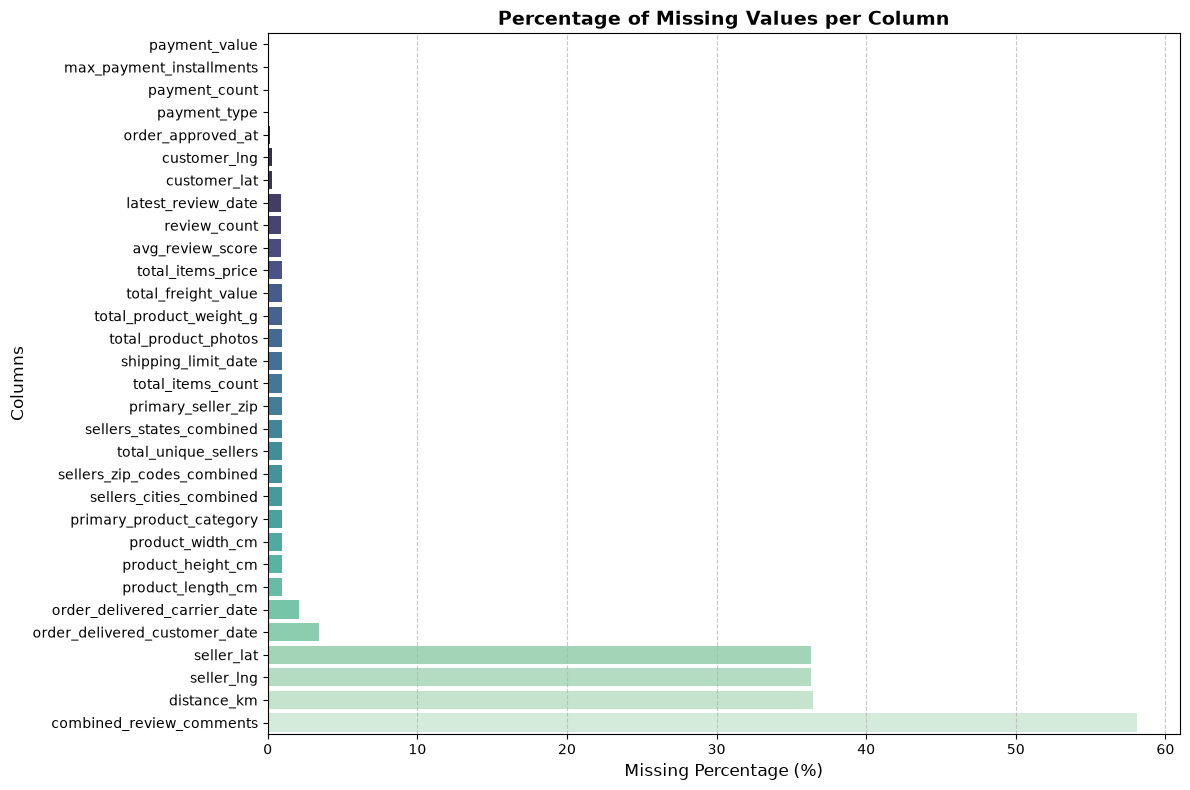

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# تصفية الأعمدة التي تحتوي على قيم مفقودة فقط وترتيبها تصاعدياً/تنازلياً للعرض
missing_percentage = (TrainingData.isnull().sum() / len(TrainingData)) * 100
missing_df_plot = missing_percentage[missing_percentage > 0].sort_values(ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(x=missing_df_plot.values, y=missing_df_plot.index, hue=missing_df_plot.index, palette="mako", legend=False)

plt.title("Percentage of Missing Values per Column", fontsize=14, fontweight='bold')
plt.xlabel("Missing Percentage (%)", fontsize=12)
plt.ylabel("Columns", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Numerical Features

- Calculate descriptive statistics.
- Examine distributions and skewness.
- Identify outliers.
- Check ranges and values that do not make business sense.

In [36]:
numerical_cols = TrainingData.select_dtypes(include=['int64', 'float64']).columns
print(TrainingData[numerical_cols].skew())

avg_review_score            -1.259479
review_count                11.808841
payment_value                9.843399
payment_count               24.416209
max_payment_installments     1.584223
total_items_count            8.073434
total_items_price           10.491206
total_freight_value          8.496228
total_product_weight_g       6.600061
product_length_cm            1.725330
product_height_cm            2.209106
product_width_cm             1.728510
total_product_photos         3.645502
total_unique_sellers        10.672394
customer_lat                 1.581224
customer_lng                -0.032557
seller_lat                   1.404565
seller_lng                   0.772959
distance_km                  1.711301
is_late                      2.921866
dtype: float64


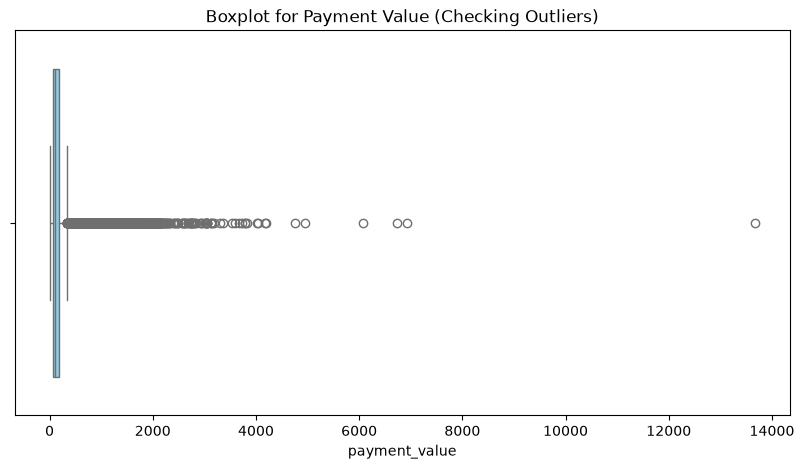

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(x=TrainingData['payment_value'], color='skyblue')
plt.title("Boxplot for Payment Value (Checking Outliers)")
plt.show()